Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
(530, 530)
>i2


NameError: name 'floats' is not defined

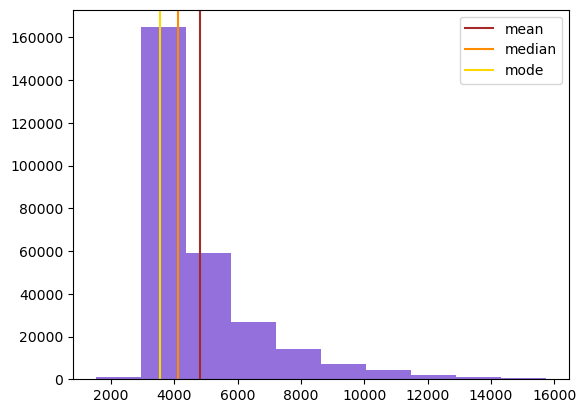

In [2]:
from astropy.io import fits
import numpy as np
from scipy.stats import mode


hdulist = fits.open('m101.fits')
hdulist.info()

hdr = hdulist[0].header

for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
    
dat = hdulist[0].data
print(np.shape(dat))
print(dat.dtype)

flat=dat.flatten()
big=flat.max()
smol=flat.min()
mean=np.mean(flat)
std=np.std(flat)
med=np.median(flat)
mod=mode(flat).mode


import matplotlib.pyplot as plt

plt.hist(flat,color='mediumpurple')
plt.axvline(mean,color='brown',label='mean')
plt.axvline(med,color='darkorange',label='median')
plt.axvline(mod,color='gold',label='mode')
plt.legend()


med2=np.median(floats)

plt.figure()
floats=np.asarray(dat,dtype='float')
plt.imshow(floats,cmap='coolwarm',vmin=med2)
plt.xlabel(hdr['CTYPE1'])
plt.ylabel(hdr['CTYPE2'])
plt.colorbar(label='counts')
hdr["BUNIT"] = "Counts"


hdulistout = fits.PrimaryHDU(floats)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('floatsm101.fits', overwrite=True, output_verify='ignore')
hdulist.close()



3444.8875771448143
3444.8875771448143
3435.9391666666666
248.13799010356897


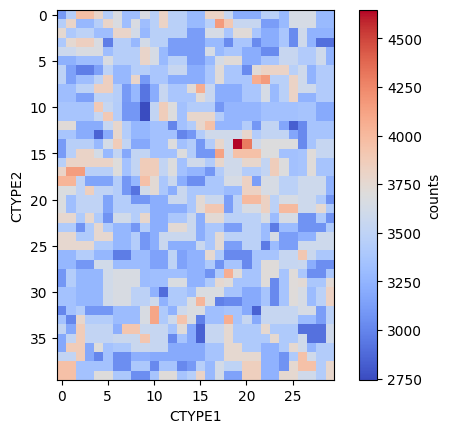

In [35]:
#6.3
from astropy.io import fits
import numpy as np
from scipy.stats import mode
import matplotlib.pyplot as plt


fits = fits.open('m101.fits')
hdr = fits[0].header
dat = fits[0].data
flat=dat.flatten()

floats=np.asarray(dat,dtype='float')

#slic=slice(40,80;90,120)
rect= dat[40:80,90:120]

x=0
for i in range(40):
    for j in range(30):
        x+=rect[i,j]**2.
                        
x=np.sqrt(x/(40*30))

y=np.sum(rect.flatten()**2.)
y=np.sqrt(y/1200)

print(x)
print(y)
print(np.mean(rect.flatten()))
print(np.std(rect.flatten()))

plt.imshow(rect,cmap='coolwarm')
plt.xlabel('CTYPE1')
plt.ylabel('CTYPE2')
plt.colorbar(label='counts')


In [51]:
#6.5
from astropy.io import fits
import numpy as np
from scipy.stats import mode


nm0 = fits.open('noisemap0.fits')
dat0 = nm0[0].data
fdat0 = dat0.flatten()

nm1 = fits.open('noisemap1.fits')
dat1 = nm1[0].data
fdat1 = dat1.flatten()

nm2 = fits.open('noisemap2.fits')
dat2 = nm2[0].data
fdat2 = dat2.flatten()


std0=np.std(fdat0)
std1=np.std(fdat1)
std2=np.std(fdat2)

print(std0,std1,std2)

stack = np.stack([dat0,dat1,dat2],axis=0)
meanim=np.mean([dat1,dat2,dat0],axis=0)
print(np.std(meanim))
print(np.sqrt(std0**2+std1**2+std2**2)/3)


#plt.imshow(meanim)

9.98401556679484 10.003955116338458 9.995349488722516
5.773191380233297
5.77029458336614


In [1]:
#6.6
from astropy.io import fits
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

#print(colnames)

t = Table(data, names=colnames)

DATAFLAG = np.asarray((
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
),dtype='int')

t.add_column(DATAFLAG,name='DATAFLAG')
M_G = t["GAIAEDR3_PHOT_G_MEAN_MAG"] + 5*np.log10(t['GAIAEDR3_PARALLAX']/1000) + 5 
M_G=M_G*DATAFLAG
for i in M_G:
    if i ==0:
        i=-1
t.add_column(M_G,name='ABS_MAG')

#tout=fits.PrimaryHDU(t)
#tout.writeto('APOGEE_update.fits', overwrite=True, output_verify='ignore')



NameError: name 'np' is not defined

42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
25.68840037029544


/tmp/ipykernel_1872789/3106104478.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=int(x)


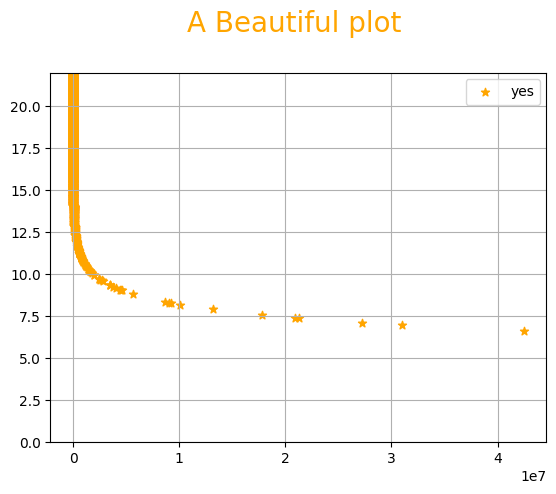

In [4]:
#6.7
import pandas as pd
import numpy as np

gaia = pdt = pd.read_csv('gaiaTestData.csv')
maxi=np.max(gaia['phot_g_mean_flux'])
print(maxi)
x=np.where(gaia['phot_g_mean_flux']==maxi)
x=np.asarray(x,dtype='int')
x=int(x)
print(gaia[64:65])

sorted = gaia.sort_values(by='phot_g_mean_flux', ascending=True)


from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt

fig = figure()
frame = fig.add_subplot(1,1,1)  
frame.set_ylim(0,np.max(gaia['phot_g_mean_flux']))
frame.set_ylim(0,np.max(gaia['phot_g_mean_mag']))
frame.scatter(gaia['phot_g_mean_flux'], gaia['phot_g_mean_mag'], marker='*',color='orange',label='yes')
frame.grid()
plt.legend()
plt.title('A Beautiful plot \n ',size=20,color='orange')

m0=2.5*np.log10(gaia['phot_g_mean_flux'])+gaia['phot_g_mean_mag']
print(np.average(m0))

show()


In [17]:
#6.10
from astroquery.gaia import Gaia
import sqlite3 as sqlite
import platform

simple_query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5  
    AND phot_bp_mean_mag IS NOT NULL 
    AND phot_rp_mean_mag IS NOT NULL 
    AND phot_g_mean_mag IS NOT NULL 
ORDER BY random_index
"""

print("Sending query to Gaia archive...")
job = Gaia.launch_job(simple_query)
results = job.get_results()

print(f"Retrieved {len(results)} stars")
print(f"\nResult type: {type(results)}")
print("\nFirst few rows:")

# Convert Astropy Table to Pandas DataFrame
df_simple = results.to_pandas()

#df_simple.writeto("astroquery_gaia.fits", overwrite=True, output_verify='ignore')
results.write("astroquery_gaia.fits",format='fits',overwrite=True)

Sending query to Gaia archive...
Retrieved 50 stars

Result type: <class 'astropy.table.table.Table'>

First few rows:


In [45]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    fib=[0,1]
    def __init__(self,N=1000):
        self.N=N
        for i in range(N):
            self.fib.append(self.fib[i+1]+self.fib[i])
        print("I created fibonacci")
    def find(self,n):
        self.n=int(n)
        return self.fib[n-1]
    def div(self,n,m):
        self.n=int(n)
        self.m=m
        r=[]
        for j in self.fib:
            if j<self.fib[n-1] and j%m==0:
                r.append(j)            
        return r
        
F=Fibonacci()
print(F.find(100))
print(F.div(100,7))

I created fibonacci
218922995834555169026
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]


In [ ]:

    the N-th term Fibonacci number 
    all Fibonacci numbers less than N-th term that can be divided by M. N and M are input parameters of the function.

Include a test in your report for N = 100, M = 7

In [44]:
fib=[0,1]
for i in range(10):
    fib.append(fib[i+1]+fib[i])
    
print(fib)

r=[]
m=2
n=8

for j in fib:
    if j<fib[n] and j%m==0:
        r.append(j) 
        
print(r)

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89]
[0, 2, 8]
